<a href="https://colab.research.google.com/github/qinghewang0628/us-college-major-roi/blob/main/college_major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 让图片更清晰
plt.rcParams['figure.dpi'] = 120
print("库导入成功")


库导入成功


In [2]:
df = pd.read_csv("college_majors_2026.csv")

print("数据集形状（行数, 列数）：", df.shape)
print("\n===== 前5行数据 =====")
print(df.head())
print("\n===== 每列数据类型和非空数量 =====")
print(df.info())


数据集形状（行数, 列数）： (227980, 72)

===== 前5行数据 =====
            program_id    unitid  opeid6  \
0  opeid031505-51.07-1       NaN   31505   
1  opeid031505-51.35-1       NaN   31505   
2  opeid031505-52.04-1       NaN   31505   
3       493868-12.04-1  493868.0   42833   
4       177834-13.06-5  177834.0    2477   

                          institution_name  institution_control  \
0                    A - Technical College  Private, for-profit   
1                    A - Technical College  Private, for-profit   
2                    A - Technical College  Private, for-profit   
3         A Better U Beauty Barber Academy  Private, for-profit   
4  A T Still University of Health Sciences   Private, nonprofit   

   is_main_campus institution_city institution_state institution_region  \
0               1              NaN               NaN                NaN   
1               1              NaN               NaN                NaN   
2               1              NaN               NaN        

In [5]:
#数据清洗
# 筛选学士学位 Bachelor's Degree
df_bachelor = df[df["credential_name"] == "Bachelor's Degree"].copy()
print(f"\n筛选本科之后行数：{df_bachelor.shape[0]}")

# 真正可用核心字段
keep_cols = [
    "cip_family_title",               # 专业大类（替代major_field）
    "median_earnings_4yr_usd",        # 毕业4年薪资
    "debt_to_earnings_1yr",           # 负债收入比
    "ai_software_occupation_share"    # AI软件岗位占比，替代ai_exposure_score
]
#df_bachelor[keep_cols]提取其中的四列，生成新的子表
df_sub = df_bachelor[keep_cols].copy()

print("\n核心字段缺失统计：")
print(df_sub.isnull().sum())

# 删除薪资、负债为空的行
before = len(df_sub)
#df_sub.dropna删除收入或负债为空的行
df_sub = df_sub.dropna(subset=["median_earnings_4yr_usd", "debt_to_earnings_1yr"])
after = len(df_sub)
#打印删除前后数量，用来记录数据损耗
print(f"\n删除缺失：之前{before}，之后{after}，删掉{before-after}行")
#`.describe()`：输出数值列的统计汇总：均值、中位数、最大最小值、四分位数。快速看数据分布，发现异常值。
print("\n描述统计：")
print(df_sub.describe())



筛选本科之后行数：71664

核心字段缺失统计：
cip_family_title                    0
median_earnings_4yr_usd         44047
debt_to_earnings_1yr            47850
ai_software_occupation_share     3279
dtype: int64

删除缺失：之前71664，之后22485，删掉49179行

描述统计：
       median_earnings_4yr_usd  debt_to_earnings_1yr  \
count             22485.000000          22485.000000   
mean              65145.659506              0.583091   
std               20650.972623              0.262118   
min               16087.000000              0.047000   
25%               50422.000000              0.390000   
50%               60180.000000              0.550000   
75%               76568.000000              0.718000   
max              297029.000000              4.223000   

       ai_software_occupation_share  
count                  21703.000000  
mean                       0.092573  
std                        0.164123  
min                        0.000000  
25%                        0.000000  
50%                        0.000000  

In [4]:
# 查看学位名称全部唯一值
print(df["credential_name"].unique())


['Undergraduate Certificate or Diploma' "Master's Degree"
 'Doctoral Degree' 'Graduate/Professional Certificate'
 'Post-baccalaureate Certificate' 'First Professional Degree'
 "Associate's Degree" "Bachelor's Degree"
 'Non-Credential Program (Preparatory Coursework/Teacher Certification)']


/tmp/ipykernel_3060/436349495.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_salary, x="median_earnings_4yr_usd", y="cip_family_title", palette="viridis")


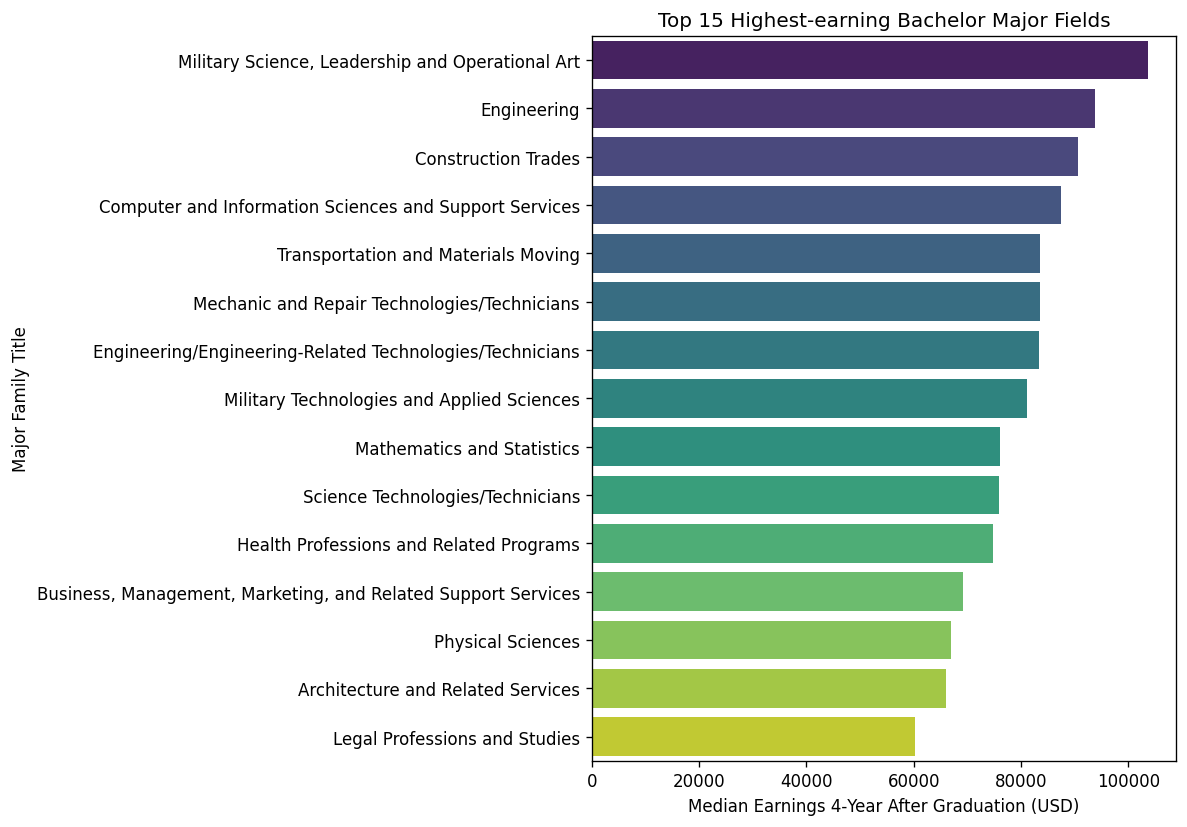


薪资最高前15专业：
                                             cip_family_title  median_earnings_4yr_usd
             Military Science, Leadership and Operational Art                 103706.0
                                                  Engineering                  93873.0
                                          Construction Trades                  90691.0
       Computer and Information Sciences and Support Services                  87413.0
                          Transportation and Materials Moving                  83613.0
                 Mechanic and Repair Technologies/Technicians                  83528.0
     Engineering/Engineering-Related Technologies/Technicians                  83322.0
                   Military Technologies and Applied Sciences                  81205.0
                                   Mathematics and Statistics                  76031.5
                             Science Technologies/Technicians                  75960.0
                      Health Pr

In [6]:
# =========分析1：薪资最高前15专业大类=========
#groupby("")按专业大类分组
#.agg()聚合函数，分组后计算：收入中位数（不受极端高薪异常影响，比平均值更适合薪资）、负债中位数、AI岗位占比平均值
#reset_index()：groupby之后，专业名称会变成索引，这个命令把它变会普通列，方便画图
group_major = df_sub.groupby("cip_family_title").agg({
    "median_earnings_4yr_usd":"median",
    "debt_to_earnings_1yr":"median",
    "ai_software_occupation_share":"mean"
}).reset_index()
#按照毕业四年后的薪资水平排序，降序，取前15个
top15_salary = group_major.sort_values("median_earnings_4yr_usd", ascending=False).head(15)

plt.figure(figsize=(10,7))#创建画布，宽10高7英寸
sns.barplot(data=top15_salary, x="median_earnings_4yr_usd", y="cip_family_title", palette="viridis")#画水平柱状图，x是薪资，y是专业名称
plt.xlabel("Median Earnings 4‑Year After Graduation (USD)")
plt.ylabel("Major Family Title")
plt.title("Top 15 Highest‑earning Bachelor Major Fields")
plt.tight_layout()#自动调整布局，防止文字被截断
plt.savefig("01_top_salary_majors.png", dpi=150, bbox_inches="tight")#把图片保存成png文件
plt.show()#在单元格里直接展示图片

print("\n薪资最高前15专业：")
print(top15_salary[["cip_family_title","median_earnings_4yr_usd"]].to_string(index=False))

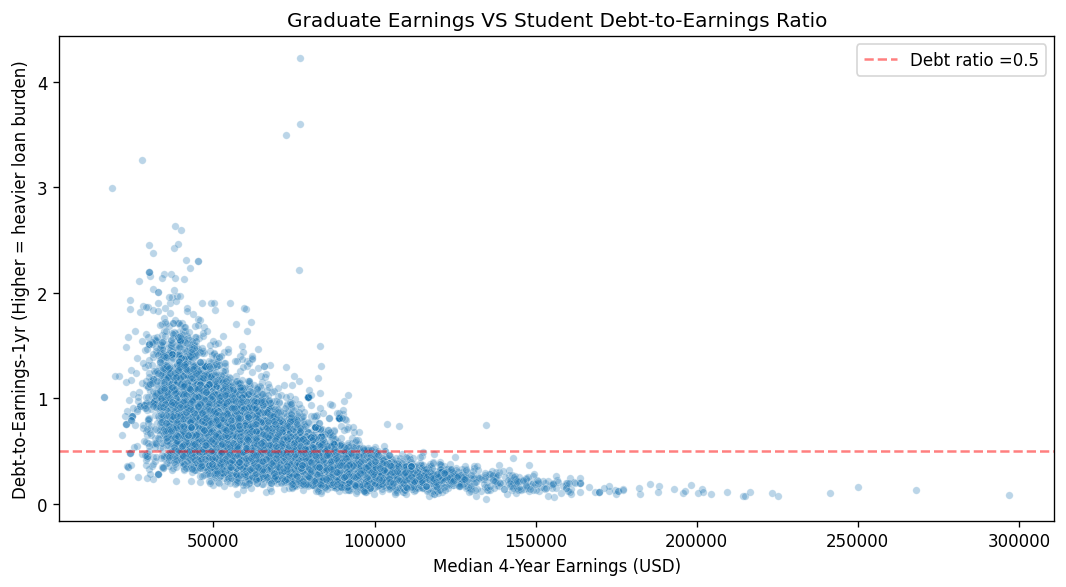


薪资中位数：$60,180
负债收入比中位数：0.55


In [7]:
#绘制散点图，观察收入高低和学生负债压力有没有关系
plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df_sub,
    x="median_earnings_4yr_usd",
    y="debt_to_earnings_1yr",
    alpha=0.3,
    s=20
)
plt.xlabel("Median 4‑Year Earnings (USD)")
plt.ylabel("Debt‑to‑Earnings‑1yr (Higher = heavier loan burden)")
plt.title("Graduate Earnings VS Student Debt‑to‑Earnings Ratio")
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Debt ratio =0.5')#红色虚线为参考线，负债比>0.5,还贷压力大
plt.legend()
plt.tight_layout()
plt.savefig("02_earnings_vs_debt.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n薪资中位数：${df_sub['median_earnings_4yr_usd'].median():,.0f}")
print(f"负债收入比中位数：{df_sub['debt_to_earnings_1yr'].median():.2f}")

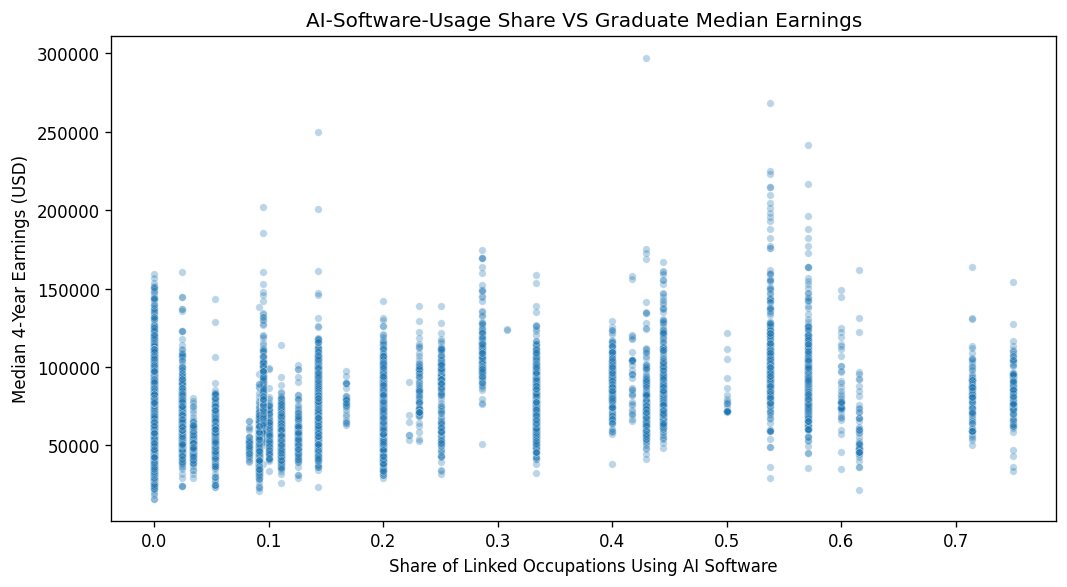


AI软件岗位占比 和薪资相关系数：0.435


In [8]:
#绘制散点图：x=岗位使用AI软件的比例，y=毕业薪资
plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df_sub,
    x="ai_software_occupation_share",
    y="median_earnings_4yr_usd",
    alpha=0.3,
    s=20
)
plt.xlabel("Share of Linked Occupations Using AI Software")
plt.ylabel("Median 4‑Year Earnings (USD)")
plt.title("AI‑Software‑Usage Share VS Graduate Median Earnings")
plt.tight_layout()
plt.savefig("03_ai_vs_salary.png", dpi=150, bbox_inches="tight")
plt.show()
#.corr()皮尔逊相关系数，看两者线性相关强弱，接近1：强正相关；接近-1强负相关，接近0几乎无相关
corr = df_sub["ai_software_occupation_share"].corr(df_sub["median_earnings_4yr_usd"])
print(f"\nAI软件岗位占比 和薪资相关系数：{corr:.3f}")

In [9]:
#筛选高回报专业：毕业四年后薪资>85000且负债收入比<0.4
good_roi = group_major[
    (group_major["median_earnings_4yr_usd"]>85000) &
    (group_major["debt_to_earnings_1yr"] <0.4)
].sort_values("median_earnings_4yr_usd", ascending=False)

print("\n====高回报专业（薪资>85000，负债比<0.4）====")
if len(good_roi)>0:
    print(good_roi.to_string(index=False))
else:
    print("无完全匹配，可下调阈值至80000 /0.5")
#筛选低收入高负债专业：毕业四年后薪资低于50000且负债收入比大于0.8
high_burden = group_major[
    (group_major["median_earnings_4yr_usd"]<50000) &
    (group_major["debt_to_earnings_1yr"]>0.8)
].sort_values("debt_to_earnings_1yr", ascending=False)

print("\n====还贷压力较高专业（薪资<50000，负债>0.8）====")
if len(high_burden)>0:
    print(high_burden.to_string(index=False))
else:
    print("无完全匹配，可以放宽条件")


====高回报专业（薪资>85000，负债比<0.4）====
                                      cip_family_title  median_earnings_4yr_usd  debt_to_earnings_1yr  ai_software_occupation_share
      Military Science, Leadership and Operational Art                 103706.0                 0.329                           NaN
                                           Engineering                  93873.0                 0.321                      0.170565
                                   Construction Trades                  90691.0                 0.286                      0.000000
Computer and Information Sciences and Support Services                  87413.0                 0.374                      0.549462

====还贷压力较高专业（薪资<50000，负债>0.8）====
                                            cip_family_title  median_earnings_4yr_usd  debt_to_earnings_1yr  ai_software_occupation_share
                                        Precision Production                  37055.0                 1.387                      0.000

In [10]:
# 保存清洗好数据
df_sub.to_csv("cleaned_bachelor_data.csv", index=False)
print("\n已输出cleaned_bachelor_data.csv和三张png图片，记得下载！")


已输出cleaned_bachelor_data.csv和三张png图片，记得下载！
